In [30]:
import pandas as pd

df = pd.read_csv("/content/startups_100.csv")

df.head()

,startup_name,industry,problem_solved,target_customer,product_description,funding_amount_usd,funding_stage,founded_year,country,success_signal,source_url,notes
0,Duolingo,Education Technology,Language learning can be expensive or hard to ...,Students and language learners,Gamified language-learning app,183000000,Public,2011,USA,Public company with a large global user base,https://tracxn.com/d/companies/duolingo/__C-GJ...,Duolingo helps users learn languages through s...
1,Coursera,Education Technology,High-quality university and career education c...,"Students, professionals, and employers","Online courses, certificates, and degree programs",443000000,Public,2012,USA,Went public and later combined with Udemy,https://tracxn.com/d/companies/coursera/__gyyW...,Coursera gives learners online access to cours...
2,Udemy,Education Technology,People need flexible ways to learn job and per...,Individual learners and business teams,Marketplace for online video courses,274000000,Merged,2010,USA,Built a global course marketplace and combined...,https://tracxn.com/d/companies/udemy/__4NtZ4yE...,Udemy lets people learn practical skills throu...
3,Quizlet,Education Technology,Studying and memorizing information can be ine...,Students and teachers,Digital flashcards and study tools,62000000,Series C,2005,USA,Reached tens of millions of monthly users,https://tracxn.com/d/companies/quizlet/__To5CM...,"Quizlet helps students study with flashcards, ..."
4,Kahoot!,Education Technology,Classroom learning can feel passive or boring,"Teachers, students, and trainers",Game-based quiz and learning platform,52300000,Acquired,2012,Norway,Acquired in a multibillion-dollar deal,https://tracxn.com/d/companies/kahoot/__P1EGOt...,Kahoot! makes lessons more interactive through...


In [31]:
df["funding_amount_numeric"] = pd.to_numeric(
    df["funding_amount_usd"],
    errors="coerce"
)

In [32]:
industry_summary = df.groupby("industry").agg(
    startup_count=("startup_name", "count"),
    average_funding=("funding_amount_numeric", "mean"),
    median_funding=("funding_amount_numeric", "median"),
    total_funding=("funding_amount_numeric", "sum")
).reset_index()

print(industry_summary)

                  industry  startup_count  average_funding  median_funding  \
0  Artificial Intelligence             20     1.995637e+10    1.334000e+09   
1            Consumer Apps             20     1.961132e+09    7.240000e+08   
2     Education Technology             20     2.942579e+08    2.400000e+08   
3                  Fintech             20     2.327378e+09    1.766000e+09   
4               Healthcare             20     7.010485e+08    5.018350e+08   

   total_funding  
0   3.791710e+11  
1   3.922265e+10  
2   5.590900e+09  
3   4.654757e+10  
4   1.402097e+10  


In [33]:
def score_startup_count(startup_count):
    """
    Score the number of startups in a category.
    Maximum score: 15 points.
    """
    if startup_count >= 20:
        return 15
    elif startup_count >= 15:
        return 12
    elif startup_count >= 10:
        return 8
    elif startup_count >= 5:
        return 5
    else:
        return 2

In [34]:
def score_average_funding(average_funding):
    """
    Score average funding amount.
    Maximum score: 20 points.
    """
    if average_funding is None:
        return 0

    if average_funding >= 1_000_000_000:
        return 20
    elif average_funding >= 500_000_000:
        return 16
    elif average_funding >= 100_000_000:
        return 12
    elif average_funding >= 10_000_000:
        return 8
    elif average_funding > 0:
        return 4
    else:
        return 0

In [35]:
MANUAL_CATEGORY_SCORES = {
    "Education Technology": {
        "growth_potential": 12,
        "problem_importance": 12,
        "teen_accessibility": 20,
        "competition_level": 12
    },
    "Artificial Intelligence": {
        "growth_potential": 15,
        "problem_importance": 12,
        "teen_accessibility": 10,
        "competition_level": 8
    },
    "Healthcare": {
        "growth_potential": 12,
        "problem_importance": 15,
        "teen_accessibility": 5,
        "competition_level": 6
    },
    "Fintech": {
        "growth_potential": 12,
        "problem_importance": 10,
        "teen_accessibility": 6,
        "competition_level": 6
    },
    "Climate Technology": {
        "growth_potential": 12,
        "problem_importance": 15,
        "teen_accessibility": 10,
        "competition_level": 12
    },
    "Gaming": {
        "growth_potential": 8,
        "problem_importance": 8,
        "teen_accessibility": 20,
        "competition_level": 8
    },
    "Consumer Apps": {
        "growth_potential": 8,
        "problem_importance": 8,
        "teen_accessibility": 16,
        "competition_level": 8
    },
    "Cybersecurity": {
        "growth_potential": 12,
        "problem_importance": 15,
        "teen_accessibility": 8,
        "competition_level": 10
    },
    "Productivity Software": {
        "growth_potential": 10,
        "problem_importance": 10,
        "teen_accessibility": 16,
        "competition_level": 10
    },
    "Robotics": {
        "growth_potential": 12,
        "problem_importance": 12,
        "teen_accessibility": 8,
        "competition_level": 10
    }
}

In [36]:
import math

def calculate_opportunity_score(category, startup_count, average_funding):
    """
    Calculate the total opportunity score for a startup category.
    Maximum score: 100 points.
    """

    count_score = score_startup_count(startup_count)

    if average_funding is None or math.isnan(average_funding):
        funding_score = 0
    else:
        funding_score = score_average_funding(average_funding)

    manual_scores = MANUAL_CATEGORY_SCORES.get(category, {
        "growth_potential": 8,
        "problem_importance": 8,
        "teen_accessibility": 8,
        "competition_level": 8
    })

    growth_score = manual_scores["growth_potential"]
    problem_score = manual_scores["problem_importance"]
    teen_score = manual_scores["teen_accessibility"]
    competition_score = manual_scores["competition_level"]

    total_score = (
        count_score
        + funding_score
        + growth_score
        + problem_score
        + teen_score
        + competition_score
    )

    return {
        "category": category,
        "startup_count_score": count_score,
        "funding_score": funding_score,
        "growth_potential_score": growth_score,
        "problem_importance_score": problem_score,
        "teen_accessibility_score": teen_score,
        "competition_level_score": competition_score,
        "total_score": total_score
    }

In [37]:
def explain_recommendation(score_result):
    """
    Create a short explanation for a category recommendation.
    """

    category = score_result["category"]
    total_score = score_result["total_score"]

    strongest_factors = []

    if score_result["teen_accessibility_score"] >= 16:
        strongest_factors.append("high teen accessibility")

    if score_result["growth_potential_score"] >= 12:
        strongest_factors.append("strong growth potential")

    if score_result["problem_importance_score"] >= 12:
        strongest_factors.append("important problems")

    if score_result["funding_score"] >= 12:
        strongest_factors.append("strong funding signals")

    if score_result["competition_level_score"] >= 12:
        strongest_factors.append("possible student-friendly niches")

    if len(strongest_factors) == 0:
        reason = "balanced but moderate scores across the selected factors"
    else:
        reason = ", ".join(strongest_factors)

    explanation = (
        f"{category} received a score of {total_score} because it shows {reason}. "
        "This recommendation is based on a simple rule-based scoring system and should be used for exploration, not as a guaranteed prediction."
    )

    return explanation

In [38]:
df["funding_amount_numeric"] = pd.to_numeric(
    df["funding_amount_usd"],
    errors="coerce"
)

In [39]:
industry_summary = df.groupby("industry").agg(
    startup_count=("startup_name", "count"),
    average_funding=("funding_amount_numeric", "mean"),
    median_funding=("funding_amount_numeric", "median"),
    total_funding=("funding_amount_numeric", "sum")
).reset_index()

industry_summary

,industry,startup_count,average_funding,median_funding,total_funding
0,Artificial Intelligence,20,1.995637e+10,1.334000e+09,3.791710e+11
1,Consumer Apps,20,1.961132e+09,7.240000e+08,3.922265e+10
2,Education Technology,20,2.942579e+08,2.400000e+08,5.590900e+09
3,Fintech,20,2.327378e+09,1.766000e+09,4.654757e+10
4,Healthcare,20,7.010485e+08,5.018350e+08,1.402097e+10


In [40]:
score_results = []

for _, row in industry_summary.iterrows():
    result = calculate_opportunity_score(
        category=row["industry"],
        startup_count=row["startup_count"],
        average_funding=row["average_funding"]
    )
    score_results.append(result)

scores_df = pd.DataFrame(score_results)

scores_df

,category,startup_count_score,funding_score,growth_potential_score,problem_importance_score,teen_accessibility_score,competition_level_score,total_score
0,Artificial Intelligence,15,20,15,12,10,8,80
1,Consumer Apps,15,20,8,8,16,8,75
2,Education Technology,15,12,12,12,20,12,83
3,Fintech,15,20,12,10,6,6,69
4,Healthcare,15,16,12,15,5,6,69


In [41]:
ranked_scores = scores_df.sort_values(
    by="total_score",
    ascending=False
)

ranked_scores

,category,startup_count_score,funding_score,growth_potential_score,problem_importance_score,teen_accessibility_score,competition_level_score,total_score
2,Education Technology,15,12,12,12,20,12,83
0,Artificial Intelligence,15,20,15,12,10,8,80
1,Consumer Apps,15,20,8,8,16,8,75
3,Fintech,15,20,12,10,6,6,69
4,Healthcare,15,16,12,15,5,6,69


In [42]:
ranked_scores["explanation"] = ranked_scores.apply(
    lambda row: explain_recommendation(row.to_dict()),
    axis=1
)

ranked_scores[["category", "total_score", "explanation"]]

,category,total_score,explanation
2,Education Technology,83,Education Technology received a score of 83 be...
0,Artificial Intelligence,80,Artificial Intelligence received a score of 80...
1,Consumer Apps,75,Consumer Apps received a score of 75 because i...
3,Fintech,69,Fintech received a score of 69 because it show...
4,Healthcare,69,Healthcare received a score of 69 because it s...


In [43]:
for rank, (_, row) in enumerate(top_categories.iterrows(), start=1):
    print(f"Rank {rank}: {row['category']}")
    print(f"Score: {row['total_score']}")
    print(f"Explanation: {row['explanation']}")
    print()

Rank 1: Education Technology
Score: 83
Explanation: Education Technology received a score of 83 because it shows high teen accessibility, strong growth potential, important problems, strong funding signals, possible student-friendly niches. This recommendation is based on a simple rule-based scoring system and should be used for exploration, not as a guaranteed prediction.

Rank 2: Artificial Intelligence
Score: 80
Explanation: Artificial Intelligence received a score of 80 because it shows strong growth potential, important problems, strong funding signals. This recommendation is based on a simple rule-based scoring system and should be used for exploration, not as a guaranteed prediction.

Rank 3: Consumer Apps
Score: 75
Explanation: Consumer Apps received a score of 75 because it shows high teen accessibility, strong funding signals. This recommendation is based on a simple rule-based scoring system and should be used for exploration, not as a guaranteed prediction.



In [44]:
ranked_scores.to_csv(
    "/content/week09_ranked_startup_categories.csv",
    index=False
)

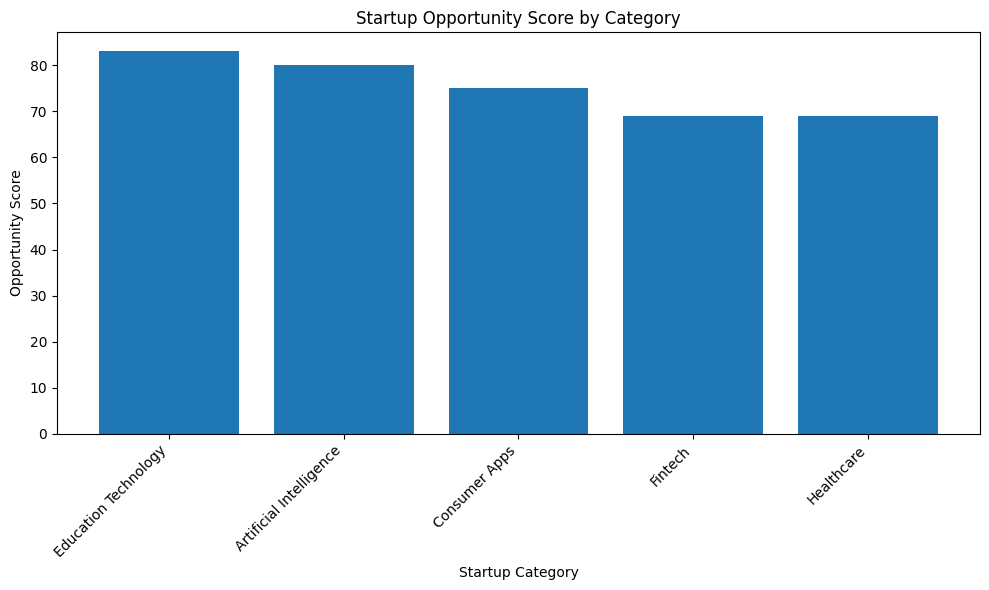

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(ranked_scores["category"], ranked_scores["total_score"])
plt.title("Startup Opportunity Score by Category")
plt.xlabel("Startup Category")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/week09_opportunity_scores.png")
plt.show()